# MÓDULO 5 — EDA Amazon Products

> - Curso: Diagnóstico y Predictibilidad | 92-0030
> - Semana 5 | I Cuatrimestre 2026 | Prof. Robin Sequeira

> - Dataset: amazon.csv — 1,466 productos de Amazon India
> - Variable objetivo: rating (calificación del producto, de 1 a 5)

### ANTES DE EJECUTAR:
   1. Confirma que el cluster de Databricks esté activo (esquina superior derecha)
   2. Verifica que amazon.csv esté disponible en la ruta PATH de abajo
   3. Ejecuta las celdas en orden: Run All o celda por celda con Shift+Enter


In [0]:
# %%

# =============================================================================
# CELDA 1 — Librerías
# Importamos todo lo que vamos a necesitar en una sola celda al inicio.
# Si seaborn no está disponible, el heatmap se imprime como tabla de texto.
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

try:
    import seaborn as sns
    SEABORN_OK = True
except ImportError:
    SEABORN_OK = False

# Ajuste de visualización: mostrar todas las columnas sin truncar
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

print("✅ Librerías cargadas correctamente.")

✅ Librerías cargadas correctamente.


In [0]:
# %%

# =============================================================================
# CELDA 2 — Carga del dataset
# Leemos el CSV y guardamos una copia limpia en df.
# NUNCA trabajamos sobre df_raw directamente: si nos equivocamos al limpiar,
# podemos volver a hacer df = df_raw.copy() sin recargar el archivo.
# =============================================================================

df_raw = spark.table("workspace.diagnosticopredictibilidad.amazon").toPandas()


df = df_raw.copy()

print(f"Dataset cargado: {df.shape[0]} filas x {df.shape[1]} columnas")
df.head()

Dataset cargado: 1465 filas x 16 columnas


,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,₹329,₹699,53%,4.2,"94,363",The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,₹154,₹399,61%,4.2,"16,905",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...


In [0]:
# %%

# =============================================================================
# CELDA 3 — Normalizar nombres de columnas
# Convertimos todos los nombres a minúsculas y reemplazamos espacios por _.
# Esto evita errores como escribir df["Discounted Price"] en vez de
# df["discounted_price"]. Las mayúsculas y espacios causan muchos bugs.
# =============================================================================

df.columns = (
    df.columns
    .str.strip()          # elimina espacios al inicio y al final
    .str.lower()          # convierte a minúsculas
    .str.replace(" ", "_") # reemplaza espacios internos por _
)

print("Columnas disponibles:")
print(df.columns.tolist())

Columnas disponibles:
['product_id', 'product_name', 'category', 'discounted_price', 'actual_price', 'discount_percentage', 'rating', 'rating_count', 'about_product', 'user_id', 'user_name', 'review_id', 'review_title', 'review_content', 'img_link', 'product_link']


In [0]:
# %%

# =============================================================================
# CELDA 4 — Diagnóstico de calidad
# Antes de limpiar, entendemos qué tan sucio está el dataset.
# isna().mean() * 100  →  porcentaje de nulos por columna
# duplicated().sum()   →  filas completamente repetidas
# nunique()            →  valores únicos por columna
#                         (alto = posible columna ID que no aporta al modelo)
# =============================================================================

print("NULOS POR COLUMNA (%):")
nulos = df.isna().mean().sort_values(ascending=False) * 100
print(nulos[nulos > 0].round(2).to_string())

print(f"\nFilas duplicadas: {df.duplicated().sum()}")

print("\nVALORES ÚNICOS POR COLUMNA (cardinalidad):")
print(df.nunique().sort_values(ascending=False).to_string())

NULOS POR COLUMNA (%):
rating_count    0.14

Filas duplicadas: 0

VALORES ÚNICOS POR COLUMNA (cardinalidad):
product_link           1465
img_link               1412
product_id             1351
product_name           1337
about_product          1293
review_content         1212
user_id                1194
user_name              1194
review_id              1194
review_title           1194
rating_count           1143
discounted_price        550
actual_price            449
category                211
discount_percentage      92
rating                   28


In [0]:
# %%

# =============================================================================
# CELDA 5 — Funciones de limpieza con regex
#
# PROBLEMA: Las columnas de precio llegan como texto, por ejemplo '₹2,499'.
# Python no puede hacer matemáticas con ese texto. Necesitamos el número 2499.0.
#
# SOLUCIÓN: Expresiones regulares (regex) para eliminar el texto no numérico.
#
# Cómo funciona re.sub(patrón, reemplazo, texto):
#   - Busca el patrón en el texto
#   - Reemplaza cada coincidencia con el reemplazo (aquí, string vacío '')
#   - Devuelve el texto limpio
#
# El patrón r"[^\d\.\-]" significa: "cualquier carácter que NO sea
# un dígito (0-9), un punto (.) o un signo negativo (-)"
#
# pd.to_numeric(..., errors='coerce'):
#   - Convierte el string limpio a número
#   - Si no puede convertir (valor raro o vacío), pone NaN en vez de dar error
# =============================================================================

def clean_currency(series):
    """
    Convierte columnas de precio: '₹2,499' → 2499.0
    Elimina símbolo de moneda, comas y cualquier texto.
    """
    s = series.astype("string")
    s = s.str.replace(r"[^\d\.\-]", "", regex=True)  # deja solo números y punto
    s = s.replace("", pd.NA)                          # vacíos → NaN
    return pd.to_numeric(s, errors="coerce")


def clean_percent(series):
    """
    Convierte columnas de porcentaje: '54%' → 54.0
    Elimina el símbolo % y cualquier texto adicional.
    """
    s = series.astype("string")
    s = s.str.replace("%", "", regex=False)           # elimina solo el %
    s = s.str.replace(r"[^\d\.\-]", "", regex=True)  # elimina cualquier otro texto
    s = s.replace("", pd.NA)
    return pd.to_numeric(s, errors="coerce")


def clean_float(series):
    """
    Convierte la columna rating: '3.9 out of 5 stars' → 3.9
    Extrae el primer número flotante que aparezca en el texto.
    """
    s = series.astype("string")
    s = s.str.replace(r"[^\d\.\-]", "", regex=True)  # deja solo el número
    s = s.replace("", pd.NA)
    return pd.to_numeric(s, errors="coerce")


print("✅ Funciones de limpieza definidas: clean_currency(), clean_percent(), clean_float()")

✅ Funciones de limpieza definidas: clean_currency(), clean_percent(), clean_float()


In [0]:
# %%

# =============================================================================
# CELDA 6 — Aplicar la limpieza
# apply(función) aplica la función fila por fila a toda la columna.
# Es equivalente a un for-loop sobre las filas, pero mucho más rápido.
# Después verificamos con dtypes: deben decir float64, no object.
# =============================================================================

df["discounted_price"]    = clean_currency(df["discounted_price"])
df["actual_price"]        = clean_currency(df["actual_price"])
df["discount_percentage"] = clean_percent(df["discount_percentage"])
df["rating"]              = clean_float(df["rating"])
df["rating_count"]        = clean_currency(df["rating_count"])

# Verificación: si alguna columna sigue siendo 'object', la limpieza falló
print("TIPOS DE DATOS DESPUÉS DE LIMPIAR:")
cols = ["discounted_price", "actual_price", "discount_percentage", "rating", "rating_count"]
print(df[cols].dtypes.to_string())

print("\nMuestra de valores limpios (primeras 5 filas):")
df[cols].head()

TIPOS DE DATOS DESPUÉS DE LIMPIAR:
discounted_price       float64
actual_price           float64
discount_percentage      int64
rating                 float64
rating_count           float64

Muestra de valores limpios (primeras 5 filas):


,discounted_price,actual_price,discount_percentage,rating,rating_count
0,399.0,1099.0,64,4.2,24269.0
1,199.0,349.0,43,4.0,43994.0
2,199.0,1899.0,90,3.9,7928.0
3,329.0,699.0,53,4.2,94363.0
4,154.0,399.0,61,4.2,16905.0


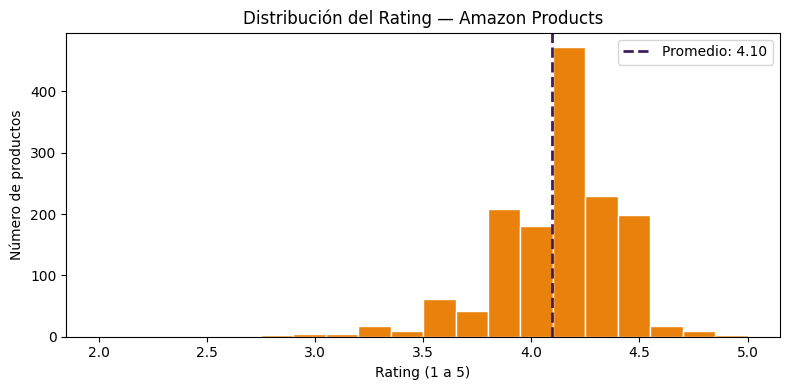

count    1464.000
mean        4.097
std         0.292
min         2.000
25%         4.000
50%         4.100
75%         4.300
max         5.000


In [0]:
# %%

# =============================================================================
# CELDA 7 — Análisis univariado: distribución del rating
# El rating es la variable objetivo. Siempre la analizamos primero.
# El histograma nos muestra si los ratings están sesgados hacia valores altos
# (sesgo positivo) o distribuidos de forma uniforme entre 1 y 5.
# La línea punteada marca el promedio para ver el sesgo visualmente.
# =============================================================================

plt.figure(figsize=(8, 4))
plt.hist(df["rating"].dropna(), bins=20, color="#E8820C", edgecolor="white")
media_rating = df["rating"].mean()
plt.axvline(media_rating, color="#3B1F5E", linestyle="--", linewidth=2,
            label=f"Promedio: {media_rating:.2f}")
plt.title("Distribución del Rating — Amazon Products")
plt.xlabel("Rating (1 a 5)")
plt.ylabel("Número de productos")
plt.legend()
plt.tight_layout()
plt.show()

print(df["rating"].describe().round(3).to_string())

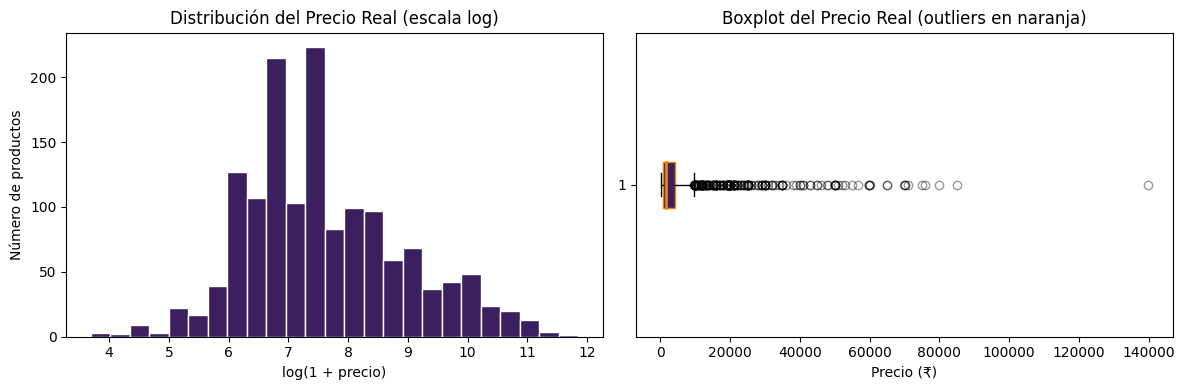

Outliers detectados en precio: 213
Q1: ₹800  |  Q3: ₹4,295  |  IQR: ₹3,495


In [0]:
# %%

# =============================================================================
# CELDA 8 — Análisis univariado: distribución del precio
# Los precios tienen distribución sesgada a la derecha: muchos productos baratos
# y pocos muy caros. Por eso usamos escala logarítmica en el eje X.
# El boxplot detecta outliers usando los bigotes del diagrama.
# Combinamos ambos gráficos para tener una vista completa.
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histograma con escala logarítmica
precios = df["actual_price"].dropna()
precios = precios[precios > 0]  # eliminamos ceros para que log no dé error
axes[0].hist(np.log1p(precios), bins=25, color="#3B1F5E", edgecolor="white")
axes[0].set_title("Distribución del Precio Real (escala log)")
axes[0].set_xlabel("log(1 + precio)")
axes[0].set_ylabel("Número de productos")

# Boxplot horizontal
axes[1].boxplot(precios, vert=False, patch_artist=True,
                boxprops=dict(facecolor="#3B1F5E", color="#E8820C"),
                medianprops=dict(color="#E8820C", linewidth=2),
                flierprops=dict(marker="o", color="#E8820C", alpha=0.4))
axes[1].set_title("Boxplot del Precio Real (outliers en naranja)")
axes[1].set_xlabel("Precio (₹)")

plt.tight_layout()
plt.show()

# Detección de outliers con la regla IQR del Módulo 2
q1  = df["actual_price"].quantile(0.25)
q3  = df["actual_price"].quantile(0.75)
iqr = q3 - q1
outliers = ((df["actual_price"] < q1 - 1.5 * iqr) |
            (df["actual_price"] > q3 + 1.5 * iqr)).sum()
print(f"Outliers detectados en precio: {outliers}")
print(f"Q1: ₹{q1:,.0f}  |  Q3: ₹{q3:,.0f}  |  IQR: ₹{iqr:,.0f}")

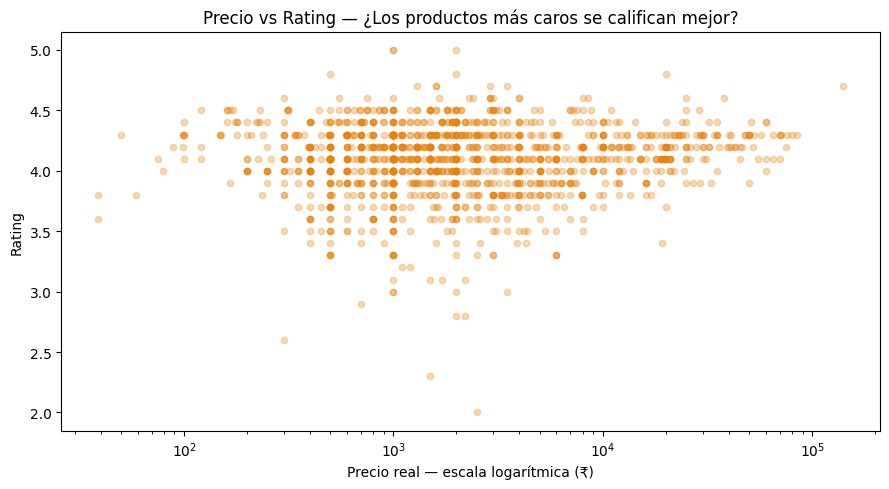

Correlación precio vs rating: 0.122
Interpretación: cercano a 0 = no hay relación lineal entre precio y rating.


In [0]:
# %%

# =============================================================================
# CELDA 9 — Análisis bivariado: precio vs rating
# ¿Los productos más caros reciben mejor calificación?
# El scatter plot cruza dos variables numéricas.
# Cada punto es un producto. Eje X = precio, Eje Y = rating.
# Usamos escala logarítmica en X porque los precios tienen mucha dispersión.
# El coeficiente de correlación nos confirma si hay relación lineal.
# =============================================================================

df_plot1 = df[["actual_price", "rating"]].dropna()
df_plot1 = df_plot1[df_plot1["actual_price"] > 0]

plt.figure(figsize=(9, 5))
plt.scatter(df_plot1["actual_price"], df_plot1["rating"],
            alpha=0.3, color="#E8820C", s=20)
plt.xscale("log")
plt.xlabel("Precio real — escala logarítmica (₹)")
plt.ylabel("Rating")
plt.title("Precio vs Rating — ¿Los productos más caros se califican mejor?")
plt.tight_layout()
plt.show()

# Correlación de Pearson entre precio y rating
corr_precio = df_plot1.corr().loc["actual_price", "rating"]
print(f"Correlación precio vs rating: {corr_precio:.3f}")
print("Interpretación: cercano a 0 = no hay relación lineal entre precio y rating.")

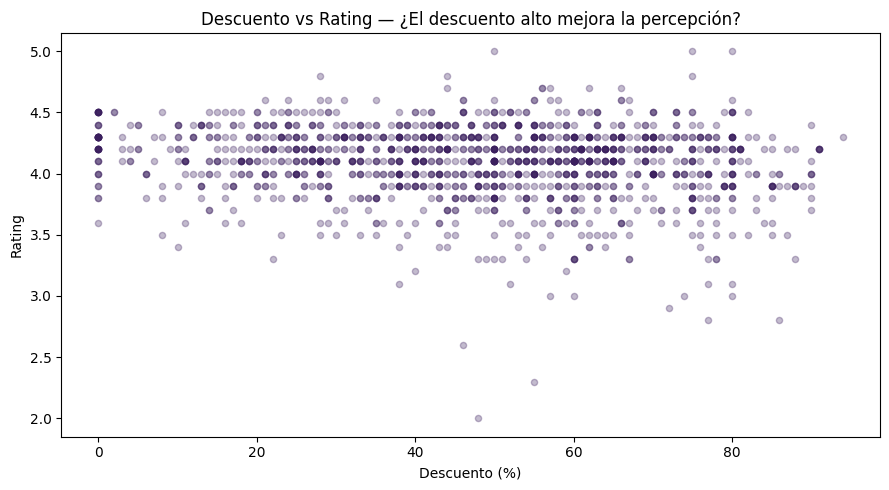

Correlación descuento vs rating: -0.155
Interpretación: si es cercano a 0, el descuento no predice el rating de forma lineal.


In [0]:
# %%

# =============================================================================
# CELDA 10 — Análisis bivariado: descuento vs rating
# ¿Un mayor descuento genera mejor o peor calificación?
# Esta celda responde la hipótesis que planteamos al inicio de la clase.
# Misma lógica que la celda anterior, pero con discount_percentage en el eje X.
# =============================================================================

df_plot2 = df[["discount_percentage", "rating"]].dropna()

plt.figure(figsize=(9, 5))
plt.scatter(df_plot2["discount_percentage"], df_plot2["rating"],
            alpha=0.3, color="#3B1F5E", s=20)
plt.xlabel("Descuento (%)")
plt.ylabel("Rating")
plt.title("Descuento vs Rating — ¿El descuento alto mejora la percepción?")
plt.tight_layout()
plt.show()

corr_desc = df_plot2.corr().loc["discount_percentage", "rating"]
print(f"Correlación descuento vs rating: {corr_desc:.3f}")
print("Interpretación: si es cercano a 0, el descuento no predice el rating de forma lineal.")

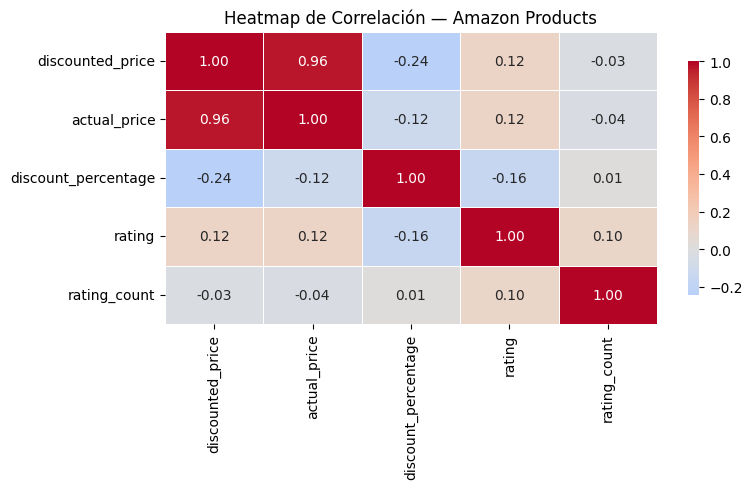


Correlaciones con la variable objetivo 'rating' (de mayor a menor):
rating                 1.000
actual_price           0.122
discounted_price       0.120
rating_count           0.102
discount_percentage   -0.155


In [0]:
# %%

# =============================================================================
# CELDA 11 — Heatmap de correlación (análisis multivariado)
# Visualizamos TODAS las correlaciones entre variables numéricas al mismo tiempo.
# Importante: select_dtypes(include='number') filtra solo columnas numéricas.
# Sin ese filtro, corr() da error si hay columnas con texto.
# La tabla al final muestra qué variable tiene más relación con el rating.
# =============================================================================

# Solo columnas numéricas
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr     = df[num_cols].corr()

if SEABORN_OK:
    plt.figure(figsize=(8, 5))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
                center=0, linewidths=0.5, cbar_kws={"shrink": 0.8})
    plt.title("Heatmap de Correlación — Amazon Products")
    plt.tight_layout()
    plt.show()
else:
    # Si seaborn no está disponible, imprimimos la matriz como tabla
    print("Matriz de correlación:")
    print(corr.round(2).to_string())

print("\nCorrelaciones con la variable objetivo 'rating' (de mayor a menor):")
print(corr["rating"].sort_values(ascending=False).round(3).to_string())

In [0]:
# %%

# =============================================================================
# CELDA 12 — Resumen de hallazgos
# Documentamos los resultados clave del EDA.
# Este bloque también sirve como guía para la presentación grupal:
# cada equipo debe poder responder estas preguntas con los números reales.
# =============================================================================

print("=" * 60)
print("RESUMEN EDA — Amazon Products | Módulo 5 Semana 5")
print("=" * 60)
print(f"  Productos analizados : {len(df)}")
print(f"  Rating promedio      : {df['rating'].mean():.2f} / 5.0")
print(f"  Rating mediano       : {df['rating'].median():.2f}")
print(f"  Precio promedio      : ₹{df['actual_price'].mean():,.0f}")
print(f"  Descuento promedio   : {df['discount_percentage'].mean():.1f}%")
print(f"  Outliers en precio   : {outliers}")
print()
print("Correlaciones con rating:")
print(corr["rating"].drop("rating").sort_values(ascending=False).round(3).to_string())
print()
print("Preguntas para la presentación grupal:")
print("  1. ¿El precio predice de forma lineal el rating?")
print("  2. ¿El descuento mejora o empeora la percepción del cliente?")
print("  3. ¿Qué variable tiene más correlación con el rating?")

# =============================================================================
# FIN DEL CÓDIGO — MÓDULO 5
# Próximo paso: Módulo 6 — Regresión Lineal con el dataset Insurance
# =============================================================================

RESUMEN EDA — Amazon Products | Módulo 5 Semana 5
  Productos analizados : 1465
  Rating promedio      : 4.10 / 5.0
  Rating mediano       : 4.10
  Precio promedio      : ₹5,445
  Descuento promedio   : 47.7%
  Outliers en precio   : 213

Correlaciones con rating:
actual_price           0.122
discounted_price       0.120
rating_count           0.102
discount_percentage   -0.155

Preguntas para la presentación grupal:
  1. ¿El precio predice de forma lineal el rating?
  2. ¿El descuento mejora o empeora la percepción del cliente?
  3. ¿Qué variable tiene más correlación con el rating?


# RESPUESTAS DE LA ACTIVAD:
---

**1 ¿El precio tiene correlación significativa con el rating? ¿Cuál es el número
exacto?** <br>
_No, el precio NO tiene correlación significativa con el rating.
El número exacto es 0.122 (correlación de Pearson)._


**2 ¿El descuento alto mejora o empeora el rating? ¿Qué dice el scatter plot?** <br>
_El descuento alto tiende ligeramente a EMPEORAR el rating, pero el efecto es mínimo.
El número exacto es -0.155 (correlación negativa muy débil)._


**3 ¿Qué columna en el heatmap tiene mayor correlación con el rating?** <br>
_La columna con mayor correlación con el rating es discount_percentage con -0.155 (en valor absoluto)._

**4. Cada grupo presenta sus 3 hallazgos más importantes.** <br>
_Tres Hallazgos Clave del EDA:_ <br>

- _El precio no predice la calidad percibida Correlación precio-rating: 0.122 Los productos caros no reciben mejores calificaciones que los baratos. La calidad percibida es completamente independiente del precio real del producto._  <br>
 
- _Los descuentos altos tienen efecto negativo (pero mínimo) Correlación descuento-rating: -0.16 (la más alta en valor absoluto) Descuentos muy altos se asocian ligeramente con ratings más bajos, posiblemente porque señalan productos en liquidación o de menor calidad. Sin embargo, el efecto es tan débil que en la práctica el descuento no influye en la percepción del cliente._  <br>

- _Las variables del dataset no predicen el rating Todas las correlaciones < 0.20_
    - _discount_percentage: -0.16_
    - _actual_price: 0.12_ 
    - _discounted_price: 0.12_
    - _rating_count: 0.10_ <br>

> _Implicación crítica: La calidad percibida de rating depende de factores no capturados en este dataset. Para predecir ratings, se necesitan datos cualitativos adicionales._


### REFLEXION

1. ¿Qué aprendí?
Que la limpieza de datos a veces requiere "cirugía fina" usando regex (expresiones regulares) para extraer números reales de campos de texto sucios (como precios con símbolos de moneda). También aprendí a usar el análisis bivariado para desmentir suposiciones de negocio con datos. Por ejemplo comprobé mediante matrices de correlación que ni el precio (0.12) ni los descuentos altos (-0.16) garantizan mejores calificaciones en los productos.

2. ¿Qué me costó más?
Por un lado, la sintaxis de las regex (re.sub) requiere mucho cuidado para limpiar los caracteres correctos sin alterar el dato real. Y estuvo interesante el ejercio de documentar en Markdown ya que es fácil caer en el error técnico de solo explicar qué hace el código en lugar de redactar una conclusión analítica que le aporte valor al negocio basándose en los gráficos.

3. ¿Dónde podría aplicar esto en mi realidad laboral?
Me sirve muchísimo para limpiar la telemetría que extraemos de GA4 en las pruebas de concepto (PoC) que estamos armando, ya que muchas veces esos reportes traen formatos de texto combinados que podré limpiar fácilmente con regex en Databricks.